In [1]:
from pathlib import Path
import ast
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

coupling_results_dir = Path(
    "/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenarios"
)
diffusion_results_dir = Path(
    "/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios"
)

results_dir = coupling_results_dir
csv_files = sorted(results_dir.glob("*.csv"))

BETA_MIN=0.01
BETA_MAX=1.0
BETA_COUNT=5

DIFFC_MIN=0.001
DIFFC_MAX=1.0
DIFFC_COUNT=5

beta_c_values = np.linspace(BETA_MIN, BETA_MAX, BETA_COUNT)
print("Beta_c values:", beta_c_values)

diffc_values = np.linspace(DIFFC_MIN, DIFFC_MAX, DIFFC_COUNT)
print("Diffc values:", diffc_values)

print("Using coupling dir:", coupling_results_dir)
print("Using diffusion dir:", diffusion_results_dir)

channel_col_names = ['Concentration', 'Hydraulic Head']

if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {results_dir}")

required_cols = {"scenario", "total_params", "n_layers", "val_l2", "val_mse", "val_rel_l2_norm_channels"}
csv_files

Beta_c values: [0.01   0.2575 0.505  0.7525 1.    ]
Diffc values: [0.001   0.25075 0.5005  0.75025 1.     ]
Using coupling dir: /Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenarios
Using diffusion dir: /Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/diffusion_scenarios


[PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenarios/coupling_scenario_01_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenarios/coupling_scenario_02_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenarios/coupling_scenario_03_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenarios/coupling_scenario_04_fno_sweep_results.csv'),
 PosixPath('/Users/arpitkapoor/Projects/groundwater/results/fno_henry_results/coupling_scenarios/coupling_scenario_05_fno_sweep_results.csv')]

In [2]:
records = []

for csv_path in csv_files:
    df = pd.read_csv(csv_path)
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path.name} is missing required columns: {sorted(missing)}")
    records.append(df.sort_values("total_params"))

plot_df = pd.concat(records, ignore_index=True)
plot_df.head()

,timestamp,scenario,model_size_label,hidden_channels,n_modes_x,n_modes_y,n_layers,total_params,train_l2,val_l2,...,batch_size,learning_rate,weight_decay,normalize,scheduler_enabled,scheduler_step_size,scheduler_decay,device,val_final_step_npz,val_final_step_plot
0,2026-04-15T10:17:08,scenario_01,tiny,48,8,16,2,695954,0.415993,0.341189,...,512,0.0008,0.0,True,True,50,0.8,cuda,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...
1,2026-04-15T10:31:55,scenario_01,small,48,8,16,4,1364210,0.376225,0.298566,...,512,0.0008,0.0,True,True,50,0.8,cuda,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...
2,2026-04-15T10:48:30,scenario_01,medium,48,8,16,6,2032466,0.359447,0.280970,...,512,0.0008,0.0,True,True,50,0.8,cuda,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...
3,2026-04-15T11:09:27,scenario_01,large,48,8,16,10,3368978,0.087803,0.101054,...,512,0.0008,0.0,True,True,50,0.8,cuda,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...
4,2026-04-14T15:05:04,scenario_01,huge,48,8,16,16,5373746,0.049629,0.054546,...,512,0.0008,0.0,True,True,50,0.8,cuda,results/validation_final_step_artifacts/scenar...,results/validation_final_step_artifacts/scenar...


In [ ]:
def parse_channel_losses(value):
    if isinstance(value, (list, tuple)):
        return [float(v) for v in value]
    if pd.isna(value):
        return []
    if isinstance(value, str):
        text = value.strip()
        if not text:
            return []
        try:
            parsed = ast.literal_eval(text)
        except (ValueError, SyntaxError):
            return []
        if isinstance(parsed, (list, tuple)):
            return [float(v) for v in parsed]
    return []

def load_and_validate_records(csv_paths, required_columns):
    records = []
    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)
        missing = required_columns - set(df.columns)
        if missing:
            raise ValueError(f"{csv_path.name} is missing required columns: {sorted(missing)}")
        records.append(df.sort_values("total_params"))
    return pd.concat(records, ignore_index=True)

def build_channel_plot_df(base_df, value_col_name, value_lookup):
    expanded_df = base_df.copy()
    expanded_df["val_rel_l2_norm_channels_parsed"] = expanded_df["val_rel_l2_norm_channels"].map(parse_channel_losses)

    max_channels = int(expanded_df["val_rel_l2_norm_channels_parsed"].map(len).max())
    if max_channels == 0:
        raise ValueError("No channel-wise validation losses found in val_rel_l2_norm_channels")

    channel_cols = [f"channel_{idx}" for idx in range(max_channels)]
    channel_loss_df = pd.DataFrame(
        expanded_df["val_rel_l2_norm_channels_parsed"].tolist(),
        columns=channel_cols,
        index=expanded_df.index,
    )

    out_df = pd.concat(
        [expanded_df[["scenario", "total_params", "n_layers"]], channel_loss_df],
        axis=1,
    )
    out_df.loc[:, value_col_name] = out_df["scenario"].apply(
        lambda s: value_lookup[int(s.split("_")[1]) - 1]
    )
    return out_df

def infer_size_to_layers_from_df(df):
    if "model_size_label" not in df.columns or "n_layers" not in df.columns:
        return {}
    mapping = (
        df[["model_size_label", "n_layers"]]
        .dropna()
        .drop_duplicates()
        .sort_values("n_layers")
    )
    return {str(row.model_size_label): int(row.n_layers) for row in mapping.itertuples(index=False)}

def plot_channel_subplots(
    data,
    x_col,
    legend_value_col,
    legend_math_symbol,
    fig_title,
    x_label,
    channel_names,
    x_log=False,
):
    plt.style.use("seaborn-v0_8-whitegrid")

    scenarios = sorted(data["scenario"].unique())
    channel_cols = [c for c in data.columns if c.startswith("channel_")]
    n_channels = len(channel_cols)

    ncols = min(3, n_channels)
    nrows = math.ceil(n_channels / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(5.2 * ncols, 4.2 * nrows),
        dpi=140,
        squeeze=False,
        sharex=True,
        sharey=False,
    )

    for idx, channel_col in enumerate(channel_cols):
        ax = axes[idx // ncols, idx % ncols]
        for scenario in scenarios:
            sub = data[data["scenario"] == scenario].sort_values(x_col)
            ax.plot(
                sub[x_col],
                sub[channel_col],
                marker="o",
                linestyle="--",
                linewidth=1.6,
                markersize=4.8,
                label=rf"${legend_math_symbol}$={sub[legend_value_col].iloc[0]:.3f}",
            )

        if x_log:
            ax.set_xscale("log")

        title = channel_names[idx] if idx < len(channel_names) else channel_col.replace("_", " ").title()
        ax.set_title(title)
        ax.set_ylabel("Validation Relative L2")
        ax.grid(True, which="both", linestyle="--", alpha=0.35)

    for idx in range(n_channels, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    for ax in axes[-1, :]:
        if ax.get_visible():
            ax.set_xlabel(x_label)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.suptitle(fig_title, y=0.995)
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=min(5, len(labels)),
        frameon=True,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

def select_npz_by_scenario_and_size(
    npz_root,
    required_sizes=("tiny", "small", "medium", "large", "huge"),
):
    candidates = sorted(npz_root.rglob("*_val_final_step.npz"))
    scenario_to_sizes = {}

    for path in candidates:
        parts = path.stem.split("_")
        if len(parts) < 6 or parts[0] != "scenario":
            continue
        scenario_idx = int(parts[1])
        size_label = parts[2]
        if size_label in required_sizes:
            scenario_to_sizes.setdefault(scenario_idx, {})[size_label] = path

    if not scenario_to_sizes:
        raise FileNotFoundError(f"No *_val_final_step.npz found under {npz_root}")

    return scenario_to_sizes

def plot_mass_concentration_grid(
    selected_npz_by_scenario_and_size,
    scenario_value_lookup,
    scenario_value_name,
    suptitle,
    prediction_sizes=("tiny", "small", "medium", "large", "huge"),
    size_to_layers=None,
    channel_idx=0,
):
    if size_to_layers is None:
        size_to_layers = {}

    scenario_ids = sorted(selected_npz_by_scenario_and_size.keys())
    nrows = len(scenario_ids)
    if nrows == 0:
        raise ValueError("No scenarios available to plot")

    ncols = 1 + len(prediction_sizes)
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(3.0 * ncols, 2 * nrows),
        dpi=140,
        squeeze=False,
    )

    row_images = []
    for row_idx, scenario_idx in enumerate(scenario_ids):
        size_map = selected_npz_by_scenario_and_size[scenario_idx]
        if not size_map:
            raise ValueError(f"No NPZ files available for scenario_{scenario_idx:02d}")

        first_path = next(iter(size_map.values()))
        with np.load(first_path) as data:
            ground_truth = data["ground_truth"][channel_idx]

        predictions = []
        available_predictions = []
        for size in prediction_sizes:
            path = size_map.get(size)
            if path is None:
                predictions.append(None)
                continue
            with np.load(path) as data:
                pred = data["prediction"][channel_idx]
            predictions.append(pred)
            available_predictions.append(pred)

        row_min = min([float(ground_truth.min())] + [float(p.min()) for p in available_predictions])
        row_max = max([float(ground_truth.max())] + [float(p.max()) for p in available_predictions])

        value = scenario_value_lookup[scenario_idx - 1]

        ax_gt = axes[row_idx, 0]
        im = ax_gt.imshow(
            ground_truth,
            origin="upper",
            cmap="Reds",
            vmin=row_min,
            vmax=row_max,
            aspect="auto",
        )
        row_images.append(im)
        ax_gt.set_title(f"Ground Truth ({scenario_value_name}={value:.3f})", fontsize=9)
        ax_gt.set_xticks([])
        ax_gt.set_yticks([])

        for col_idx, (size, pred) in enumerate(zip(prediction_sizes, predictions), start=1):
            ax = axes[row_idx, col_idx]
            layer_text = f"layers: {size_to_layers[size]}" if size in size_to_layers else f"layers: {size}"
            if pred is None:
                ax.set_facecolor("white")
                ax.text(
                    0.5,
                    0.5,
                    f"Missing\n{layer_text}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black",
                    transform=ax.transAxes,
                )
                ax.set_title(f"Prediction ({layer_text}, {scenario_value_name}={value:.3f})", fontsize=9)
                ax.set_xticks([])
                ax.set_yticks([])
                continue

            ax.imshow(
                pred,
                origin="upper",
                cmap="Reds",
                vmin=row_min,
                vmax=row_max,
                aspect="auto",
            )
            ax.set_title(f"Prediction ({layer_text}, {scenario_value_name}={value:.3f})", fontsize=9)
            ax.set_xticks([])
            ax.set_yticks([])

    fig.suptitle(suptitle, y=0.995)
    fig.subplots_adjust(top=0.94, right=0.94, wspace=0.05, hspace=0.16)

    for row_idx, im in enumerate(row_images):
        last_ax = axes[row_idx, -1]
        pos = last_ax.get_position()
        cax = fig.add_axes([pos.x1 + 0.004, pos.y0, 0.008, pos.height])
        fig.colorbar(im, cax=cax)

    plt.show()

plot_channels_df = build_channel_plot_df(
    base_df=plot_df,
    value_col_name="beta_c",
    value_lookup=beta_c_values,
)
plot_channels_df.head()

,scenario,total_params,n_layers,channel_0,channel_1,beta_c
0,scenario_01,695954,2,0.116997,0.565380,0.01
1,scenario_01,1364210,4,0.040111,0.557021,0.01
2,scenario_01,2032466,6,0.023330,0.538611,0.01
3,scenario_01,3368978,10,0.022108,0.179999,0.01
4,scenario_01,5373746,16,0.023663,0.085429,0.01


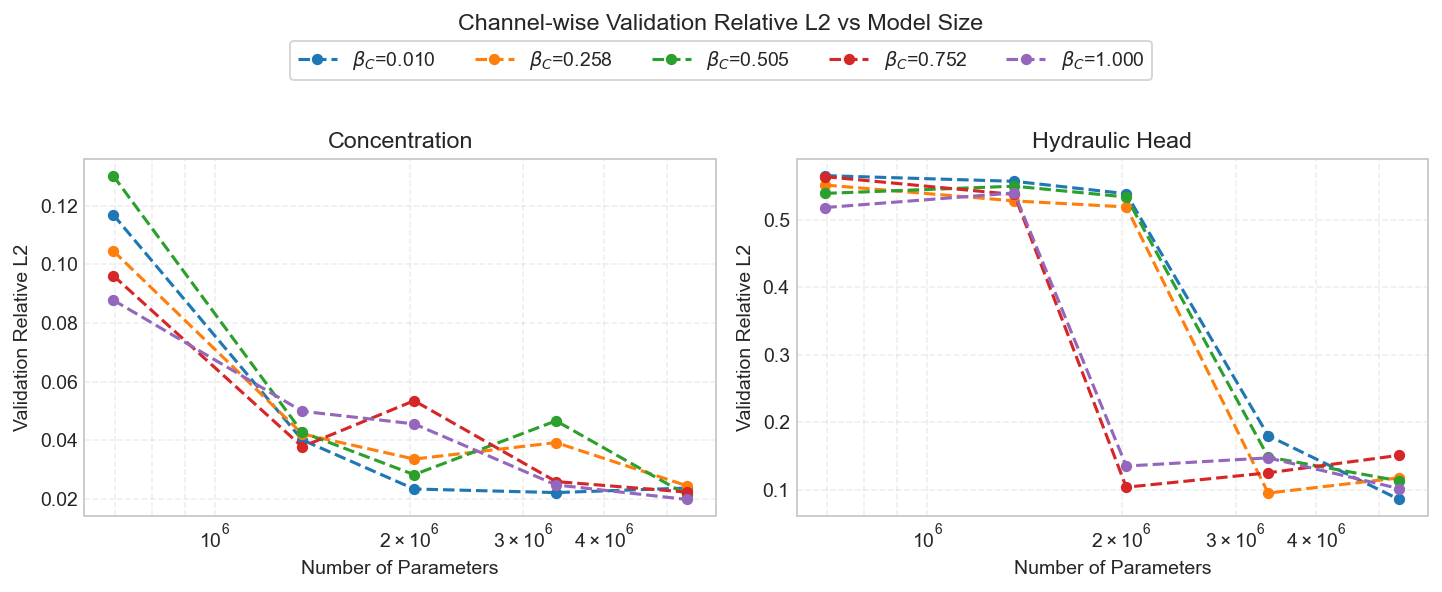

In [4]:
plot_channel_subplots(
    data=plot_channels_df,
    x_col="total_params",
    legend_value_col="beta_c",
    legend_math_symbol=r"\beta_C",
    fig_title="Channel-wise Validation Relative L2 vs Model Size",
    x_label="Number of Parameters",
    channel_names=channel_col_names,
    x_log=True,
 )

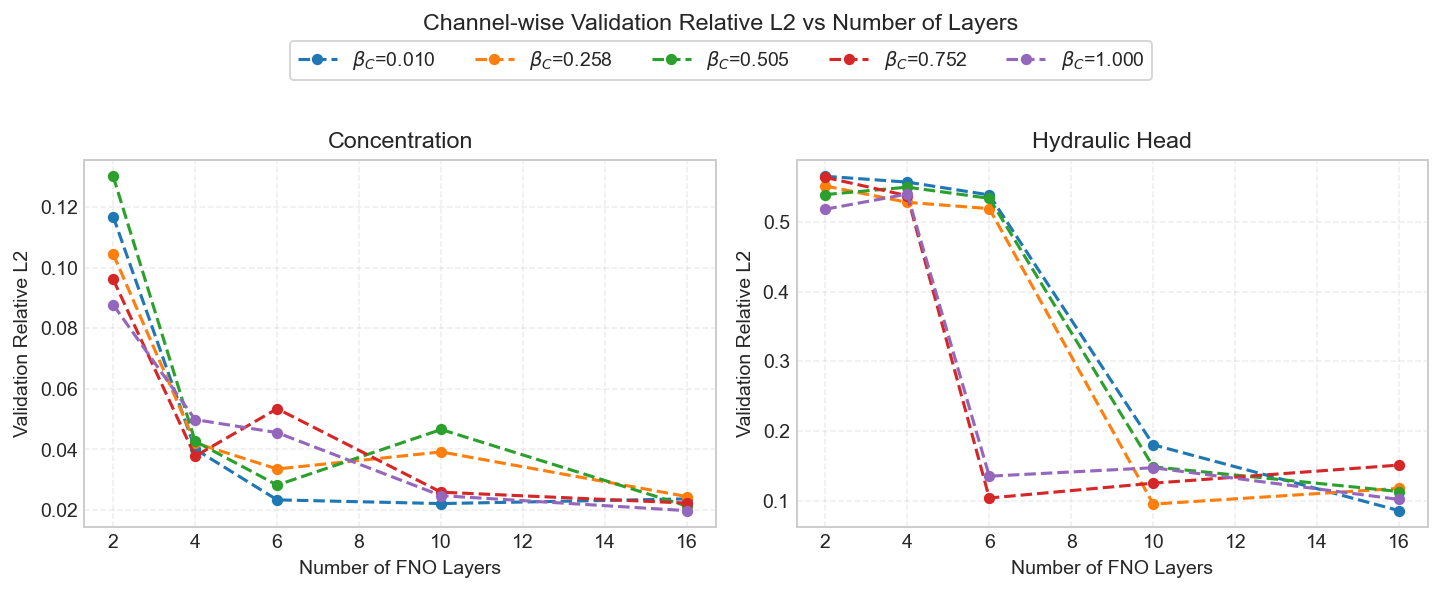

In [5]:
plot_channel_subplots(
    data=plot_channels_df,
    x_col="n_layers",
    legend_value_col="beta_c",
    legend_math_symbol=r"\beta_C",
    fig_title="Channel-wise Validation Relative L2 vs Number of Layers",
    x_label="Number of FNO Layers",
    channel_names=channel_col_names,
    x_log=False,
 )

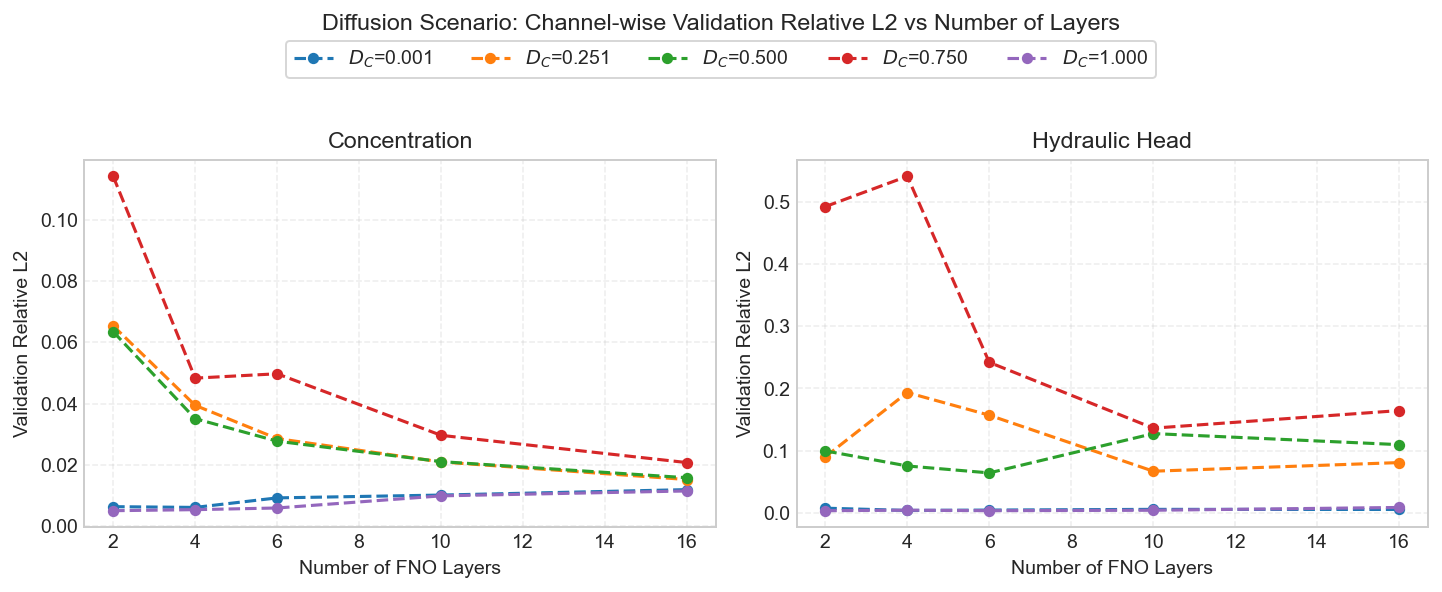

In [6]:
diffusion_csv_files = sorted(diffusion_results_dir.glob("*.csv"))
if not diffusion_csv_files:
    raise FileNotFoundError(f"No CSV files found in {diffusion_results_dir}")

diffusion_plot_df = load_and_validate_records(
    csv_paths=diffusion_csv_files,
    required_columns=required_cols,
 )
diffusion_plot_channels_df = build_channel_plot_df(
    base_df=diffusion_plot_df,
    value_col_name="diffc",
    value_lookup=diffc_values,
 )

plot_channel_subplots(
    data=diffusion_plot_channels_df,
    x_col="n_layers",
    legend_value_col="diffc",
    legend_math_symbol=r"D_C",
    fig_title="Diffusion Scenario: Channel-wise Validation Relative L2 vs Number of Layers",
    x_label="Number of FNO Layers",
    channel_names=channel_col_names,
    x_log=False,
 )

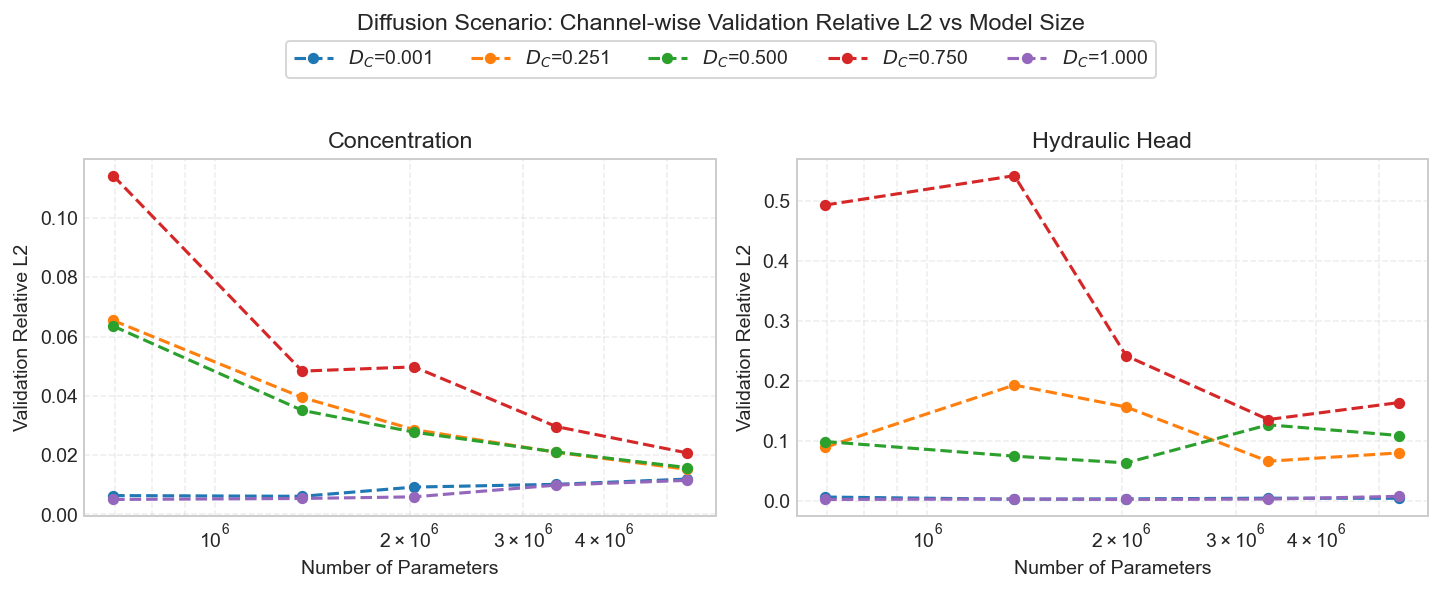

In [7]:
plot_channel_subplots(
    data=diffusion_plot_channels_df,
    x_col="total_params",
    legend_value_col="diffc",
    legend_math_symbol=r"D_C",
    fig_title="Diffusion Scenario: Channel-wise Validation Relative L2 vs Model Size",
    x_label="Number of Parameters",
    channel_names=channel_col_names,
    x_log=True,
 )

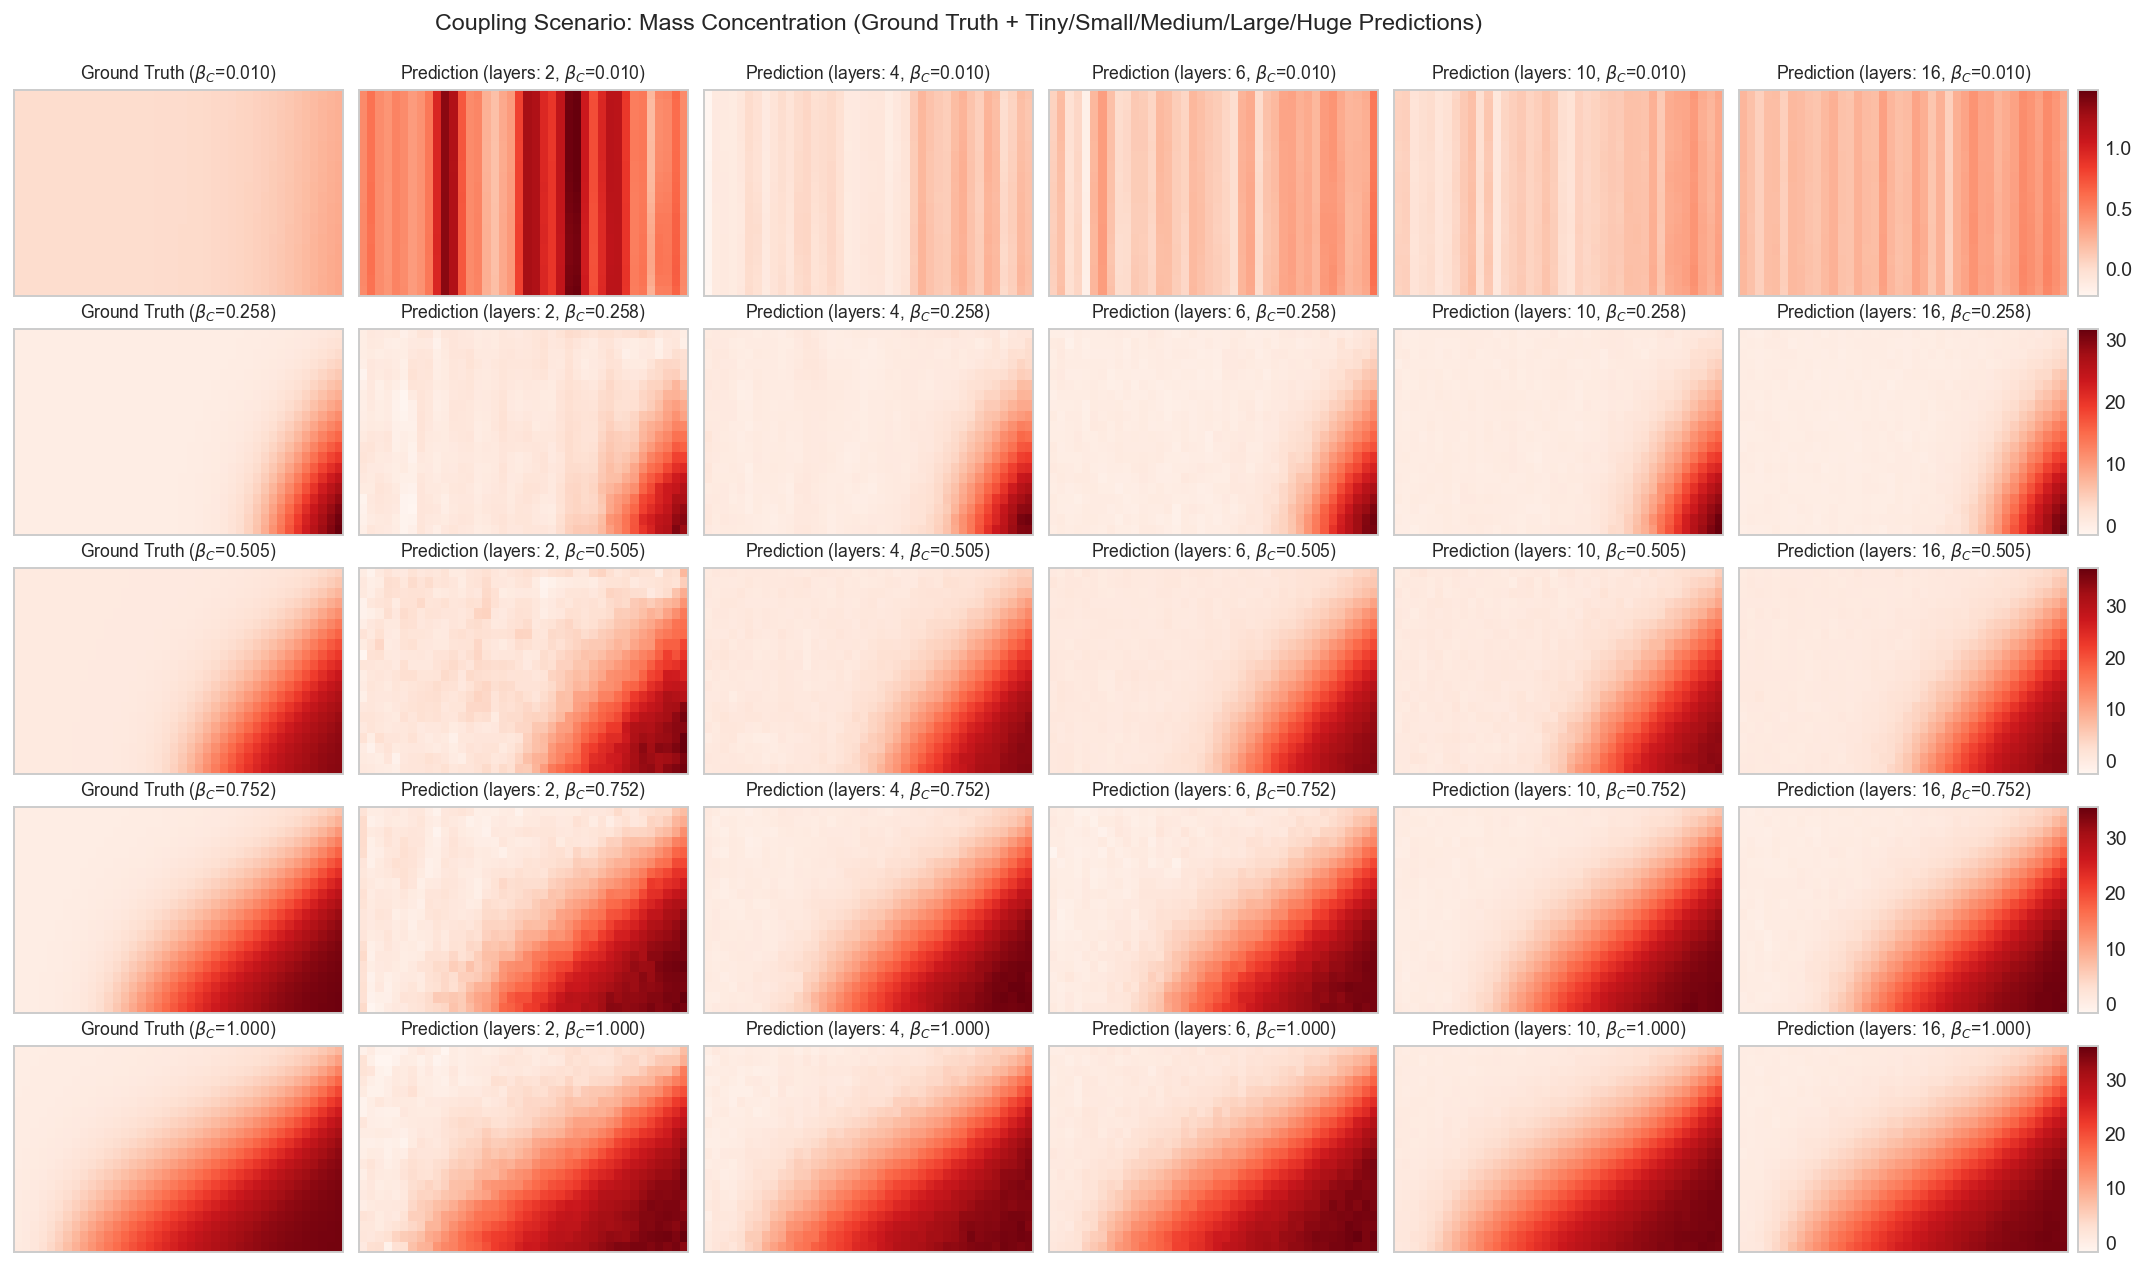

In [8]:
coupling_npz_files = select_npz_by_scenario_and_size(
    coupling_results_dir / "validation_final_step_artifacts",
    required_sizes=("tiny", "small", "medium", "large", "huge"),
 )

coupling_size_to_layers = infer_size_to_layers_from_df(plot_df)

plot_mass_concentration_grid(
    selected_npz_by_scenario_and_size=coupling_npz_files,
    scenario_value_lookup=beta_c_values,
    scenario_value_name=r"$\beta_C$",
    suptitle="Coupling Scenario: Mass Concentration (Ground Truth + Tiny/Small/Medium/Large/Huge Predictions)",
    prediction_sizes=("tiny", "small", "medium", "large", "huge"),
    size_to_layers=coupling_size_to_layers,
    channel_idx=0,
 )

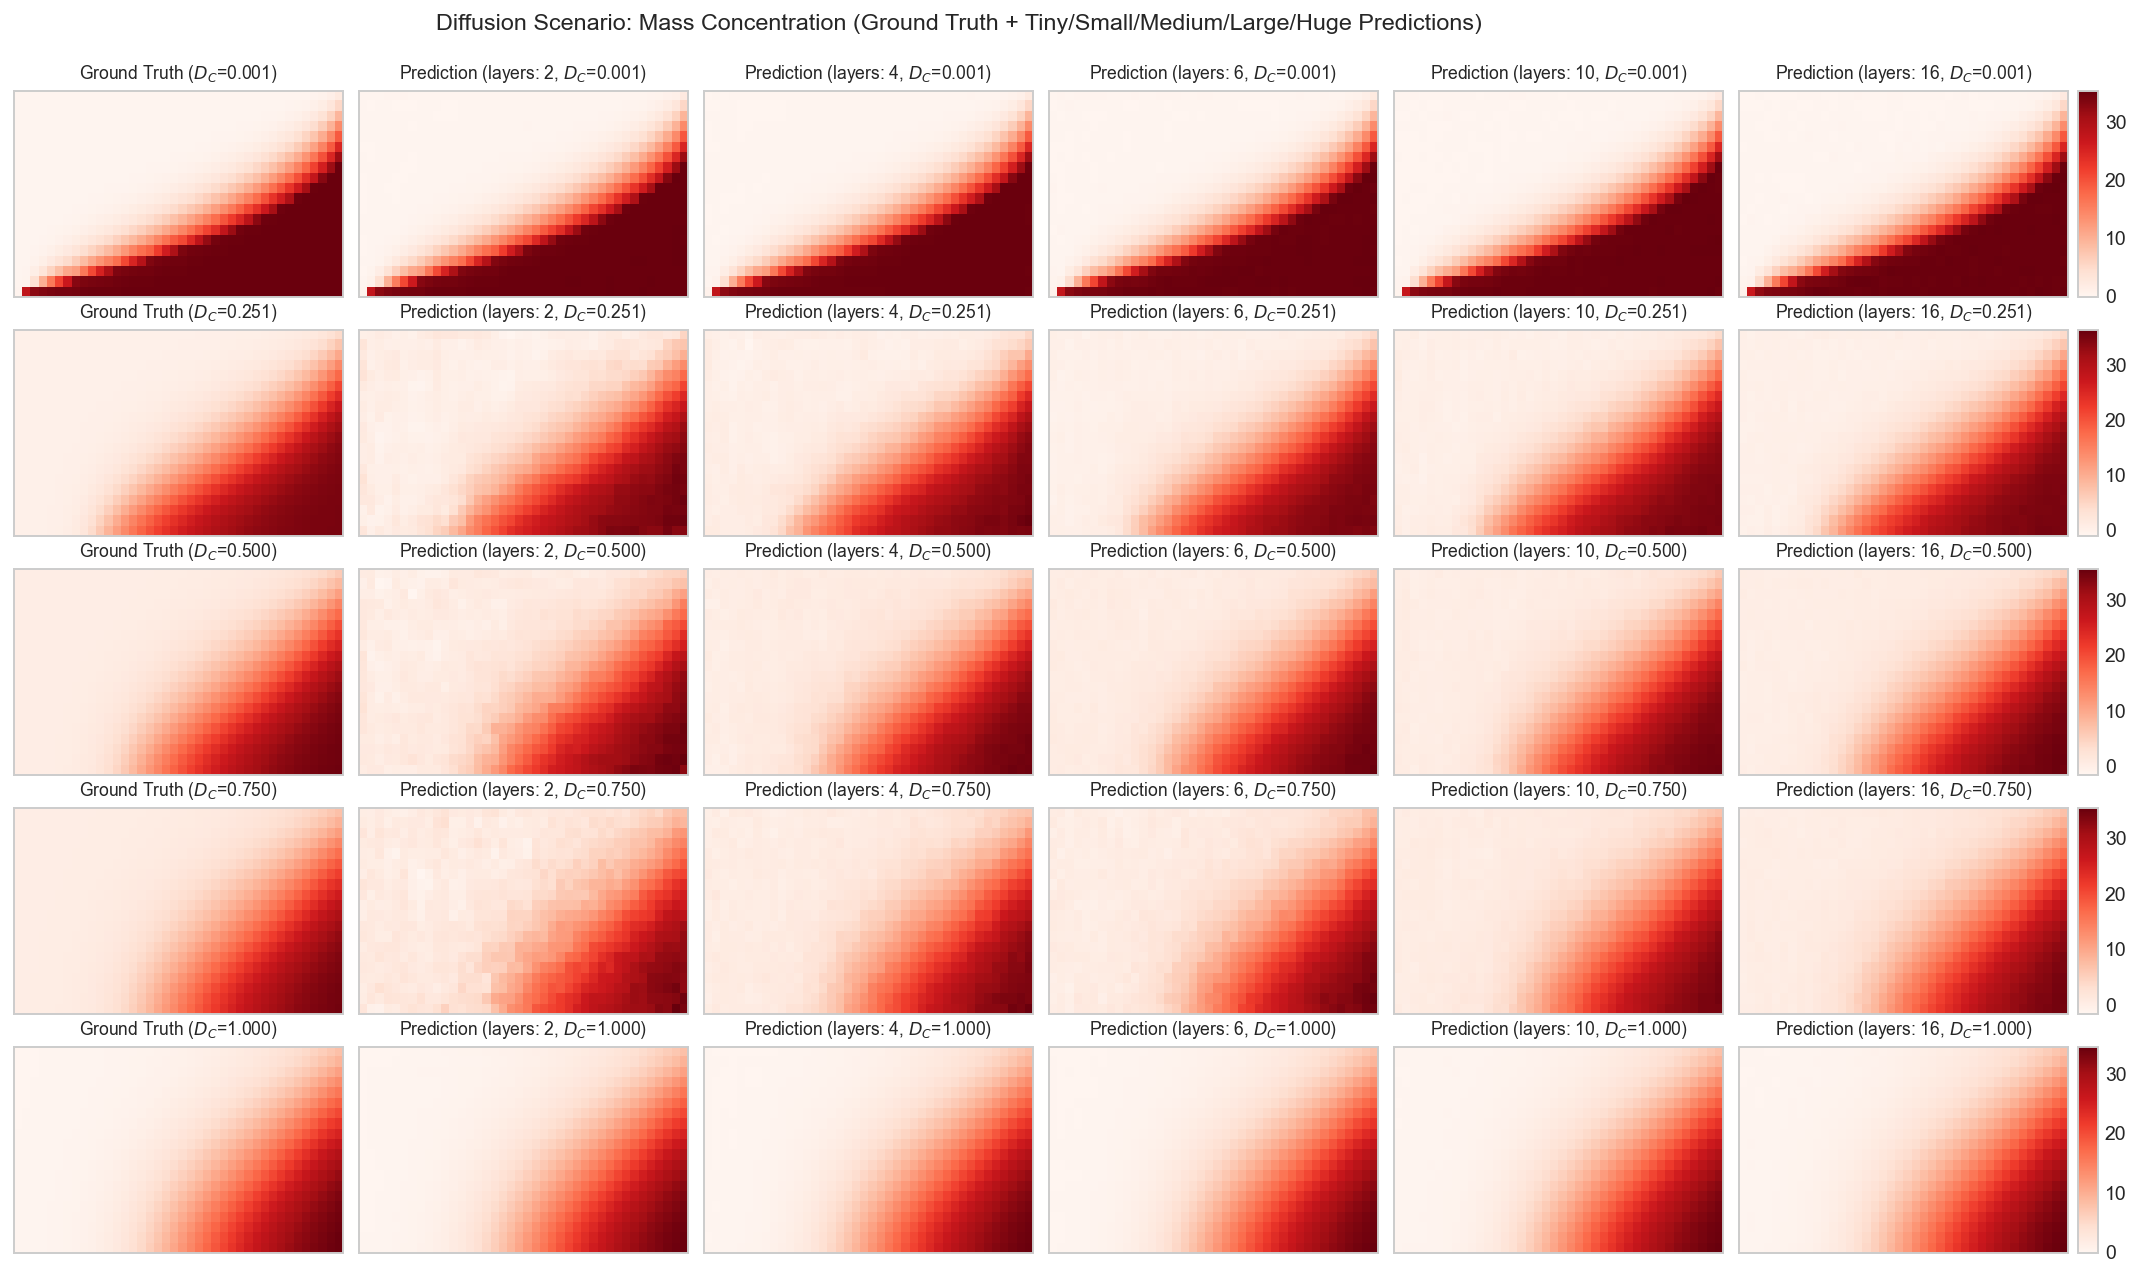

In [10]:
diffusion_npz_files = select_npz_by_scenario_and_size(
    diffusion_results_dir / "validation_final_step_artifacts",
    required_sizes=("tiny", "small", "medium", "large", "huge"),
 )

diffusion_size_to_layers = infer_size_to_layers_from_df(diffusion_plot_df)

plot_mass_concentration_grid(
    selected_npz_by_scenario_and_size=diffusion_npz_files,
    scenario_value_lookup=diffc_values,
    scenario_value_name=r"$D_C$",
    suptitle="Diffusion Scenario: Mass Concentration (Ground Truth + Tiny/Small/Medium/Large/Huge Predictions)",
    prediction_sizes=("tiny", "small", "medium", "large", "huge"),
    size_to_layers=diffusion_size_to_layers,
    channel_idx=0,
 )